In [1]:
from melodies_monet import driver

### Driver class

Now lets create an instance of the python driver analysis class. It consists of 4 main parts; model instances, observation instances, a paired instance of both. This will allow us to move things around the plotting function for spatial and overlays and more complex plots.


In [2]:
control_fn='../yaml/control_wrfchem_aircraft_sumpmspecies.yaml'
an = driver.analysis()
an.control=control_fn
an.read_control() 
an.control_dict  

{'analysis': {'start_time': '2023-08-02-00:00:00',
  'end_time': '2023-08-02-23:59:00',
  'output_dir': './output/sumvars',
  'debug': True},
 'model': {'wrfchem_v4.2': {'files': '/wrk/d2/rschwantes/MM_example_data/output_w_3hr_raqms_fire_correct/wrfout_d01_2023-08-02*',
   'mod_type': 'wrfchem',
   'mod_kwargs': {'mech': 'racm_esrl_vcp'},
   'radius_of_influence': 12000,
   'mapping': {'aeromma': {'oa_tot': 'AMS_Org',
     'SO4A': 'AMS_SO4',
     'NH4A': 'AMS_NH4',
     'NO3A': 'AMS_NO3',
     'EC': 'BC_mass_90_550_nm_amb'}},
   'variables': {'pres_pa_mid': {'rename': 'pressure_model',
     'unit_scale': 1,
     'unit_scale_method': '*'},
    'temperature_k': {'rename': 'temp_model',
     'unit_scale': 1,
     'unit_scale_method': '*'}},
   'variable_summing': {'oa_tot': {'vars': ['orgpai',
      'orgpaj',
      'asoa1i',
      'asoa1j',
      'asoa2i',
      'asoa2j',
      'asoa3i',
      'asoa3j',
      'asoa4i',
      'asoa4j',
      'bsoa1i',
      'bsoa1j',
      'bsoa2i',
     

### Loading the model data

driver will automatically loop through the "models" found in the model section of the yaml file and create an instance of the driver.model class for each that includes the label, mapping information, and xarray object as well as the filenames. Note it can open multiple files easily by including hot keys 

In [3]:
an.open_models()

wrfchem
/wrk/d2/rschwantes/MM_example_data/output_w_3hr_raqms_fire_correct/wrfout_d01_2023-08-02*
**** Reading WRF-Chem model output...


/home/rschwantes/miniconda3/envs/melodies-monet-pandas2/lib/python3.11/site-packages/monetio/models/_wrfchem_mm.py:149: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dset = xr.merge(var_wrf_list)
/home/rschwantes/miniconda3/envs/melodies-monet-pandas2/lib/python3.11/site-packages/monetio/models/_wrfchem_mm.py:149: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or

In [4]:
an.models['wrfchem_v4.2'].obj

<xarray.Dataset> Size: 22GB
Dimensions:         (y: 284, x: 440, time: 24, z: 50, bottom_top_stag: 51)
Coordinates:
    longitude       (y, x) float32 500kB -122.3 -122.2 -122.1 ... -60.52 -60.37
    latitude        (y, x) float32 500kB 21.19 21.22 21.24 ... 50.28 50.24 50.2
  * time            (time) datetime64[ns] 192B 2023-08-02 ... 2023-08-02T23:0...
Dimensions without coordinates: y, x, z, bottom_top_stag
Data variables: (12/38)
    no3aj           (time, z, y, x) float32 600MB 4.386e-08 ... 1.064e-15
    so4ai           (time, z, y, x) float32 600MB 0.002492 ... 9.998e-05
    no3ai           (time, z, y, x) float32 600MB 3.845e-09 ... 1.059e-15
    bsoa4i          (time, z, y, x) float32 600MB 3.297e-13 ... 9.998e-17
    asoa3j          (time, z, y, x) float32 600MB 1.553e-07 ... 9.998e-17
    bsoa2i          (time, z, y, x) float32 600MB 1.383e-10 ... 9.998e-17
    ...              ...
    dz_m            (time, z, y, x) float32 600MB 22.72 22.72 ... 1.377e+03
    oa_tot          (time, z, y, x) float32 600MB 0.0008293 ... 1.054e-08
    SO4A            (time, z, y, x) float32 600MB 0.0309 0.0309 ... 0.0001066
    NH4A            (time, z, y, x) float32 600MB 0.002371 ... 2.122e-15
    NO3A            (time, z, y, x) float32 600MB 4.771e-08 ... 2.123e-15
    EC              (time, z, y, x) float32 600MB 0.0008493 ... 2.36e-15
Attributes: (12/15)
    FieldType:                 104
    MemoryOrder:               XYZ
    description:               Nitrate  conc. Acc. mode
    units:                     ug/kg-dryair
    stagger:                   
    coordinates:               XLONG XLAT XTIME
    ...                        ...
    MOAD_CEN_LAT:              39.67239
    STAND_LON:                 -97.0
    MAP_PROJ:                  1
    CEN_LAT:                   39.67239
    CEN_LON:                   -97.70499
    mapping_tables_to_airnow:  {'OZONE': 'o3', 'PM2.5': 'PM2_5_DRY', 'PM10': ...

In the control file, among others, we have directed the variables 'so4aj' and 'so4ai' to be summed into the variable 'SO4A'. The results confirming this can be seen below.

In [5]:
an.models['wrfchem_v4.2'].obj['so4aj'].sum(dim=['time','z','y','x']) + an.models['wrfchem_v4.2'].obj['so4ai'].sum(dim=['time','z','y','x'])

<xarray.DataArray ()> Size: 4B
array(2.4575478e+07, dtype=float32)
Attributes: (12/14)
    FieldType:     104
    MemoryOrder:   XYZ
    stagger:       
    coordinates:   XLONG XLAT XTIME
    projection:    LambertConformal(stand_lon=-97.0, moad_cen_lat=39.67238998...
    TRUELAT1:      33.0
    ...            ...
    STAND_LON:     -97.0
    MAP_PROJ:      1
    CEN_LAT:       39.67239
    CEN_LON:       -97.70499
    description:   temperature
    units:         $\mu g m^{-3}$

In [6]:
an.models['wrfchem_v4.2'].obj['SO4A'].sum(dim=['time','z','y','x'])

<xarray.DataArray 'SO4A' ()> Size: 4B
array(2.457548e+07, dtype=float32)
Attributes: (12/14)
    FieldType:     104
    MemoryOrder:   XYZ
    stagger:       
    coordinates:   XLONG XLAT XTIME
    projection:    LambertConformal(stand_lon=-97.0, moad_cen_lat=39.67238998...
    TRUELAT1:      33.0
    ...            ...
    STAND_LON:     -97.0
    MAP_PROJ:      1
    CEN_LAT:       39.67239
    CEN_LON:       -97.70499
    description:   temperature
    units:         $\mu g m^{-3}$

### Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format. We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....). Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label 

In [7]:
an.open_obs()

/home/rschwantes/MONET/v1.1/test_examples/MELODIES-MONET/melodies_monet/util/read_util.py:224: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [8]:
an.obs['aeromma'].obj

<xarray.Dataset> Size: 4MB
Dimensions:                           (time: 967)
Coordinates:
  * time                              (time) datetime64[ns] 8kB 2023-08-02T14...
Data variables: (12/505)
    HCOOH_NOAACIMS                    (time) float64 8kB 929.7 1.077e+03 ... nan
    SO2_CIT                           (time) float64 8kB 227.5 219.9 ... nan
    PAN_NOAACIMS                      (time) float64 8kB 374.4 396.9 ... nan
    APAN_NOAACIMS                     (time) float64 8kB 5.67 6.096 ... nan
    PPN_NOAACIMS                      (time) float64 8kB 38.69 40.14 ... nan
    NO3_NNOx                          (time) float64 8kB nan nan ... -0.6 nan
    ...                                ...
    cloud_removal_flag                (time) float64 8kB 0.0 0.0 0.0 ... 0.0 nan
    abs_dry_405                       (time) float64 8kB 6.183 5.512 ... nan
    abs_dry_532                       (time) float64 8kB 0.4709 -0.448 ... nan
    abs_dry_664                       (time) float64 8kB 2.004 2.201 ... nan
    abs_TD_405                        (time) float64 8kB 7.282 6.653 ... nan
    abs_TD_664                        (time) float64 8kB nan nan ... 27.97 nan

### Variable transformations from std to amb

For several of the aerosol variables in the AEROMMA dataset, we must convert the values from standard to ambient conditions. This can be achieved with the MELODIES MONET tool melodies_monet.util.tools.convert_std_to_amb.

This function assumes STP as Pressure = 101325 Pa and Temperature = 273.15 K. Users can also optionally specify a different standard pressure and temperature using the parameters "standard_pressure" and "standard_temperature" if the observations use a different definition of STP. Please check the observation files for each campaign to ensure you use the correct STP in this conversion. The units of the temperature variable must be K and the units of the pressure variable must be Pa.

This is shown below. The dataset is provided directly to the function and modified such that the dataset will contain the converted values. This also provides an example of how users can adjust their datasets with more complex unit conversions prior to MELODIES MONET pairing for more complex analysis.

For the AEROMMA dataset the BC instrument provides ambient values, so no need for a conversion here.

In [9]:
an.obs['aeromma'].obj['AMS_Org'].sum(dim=['time'])

<xarray.DataArray 'AMS_Org' ()> Size: 8B
array(9723.03100695)

In [10]:
from melodies_monet.util.tools import convert_std_to_amb

In [11]:
convert_std_to_amb(an.obs['aeromma'].obj,convert_vars=['AMS_Org','AMS_SO4','AMS_NH4','AMS_NO3'],
                                                    temp_var='temp_obs',pres_var='pressure_obs')

In [12]:
an.obs['aeromma'].obj['AMS_Org'].sum(dim=['time'])

<xarray.DataArray 'AMS_Org' ()> Size: 8B
array(8322.36404395)

In [13]:
an.pair_data()

1, in pair data
Note: Point np.int64(965), is below the mid-point of the lowest model level and nearest neighbor extrapolation occurs for vertical pairing.
Note: Point np.int64(966), is below the mid-point of the lowest model level and nearest neighbor extrapolation occurs for vertical pairing.
After pairing:                     time  HCOOH_NOAACIMS     SO2_CIT  PAN_NOAACIMS  \
0   2023-08-02 14:50:00      929.658353  227.525000    374.421706   
1   2023-08-02 14:50:30     1077.458933  219.913333    396.874967   
2   2023-08-02 14:51:00     1145.292167  205.846667    391.295600   
3   2023-08-02 14:51:30     1374.123600  149.326667    368.964967   
4   2023-08-02 14:52:00     2376.402600   60.826667    395.997767   
..                  ...             ...         ...           ...   
962 2023-08-02 22:51:00     1143.725367  409.213333    374.434100   
963 2023-08-02 22:51:30     1118.314800  439.140000    358.808933   
964 2023-08-02 22:52:00     1107.037962  442.066667    349.936067  

Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}
Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_Org.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...
Processing scatter density plot for model 'wrfchem_v4.2' and observation 'aeromma'...
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_Org.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...


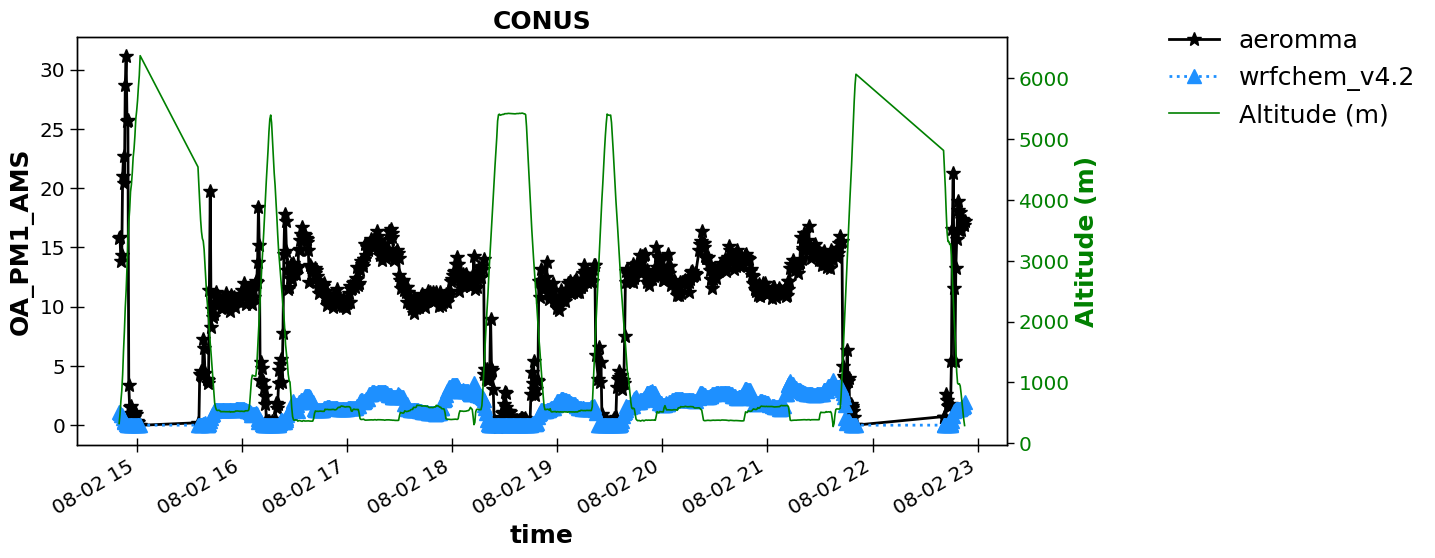

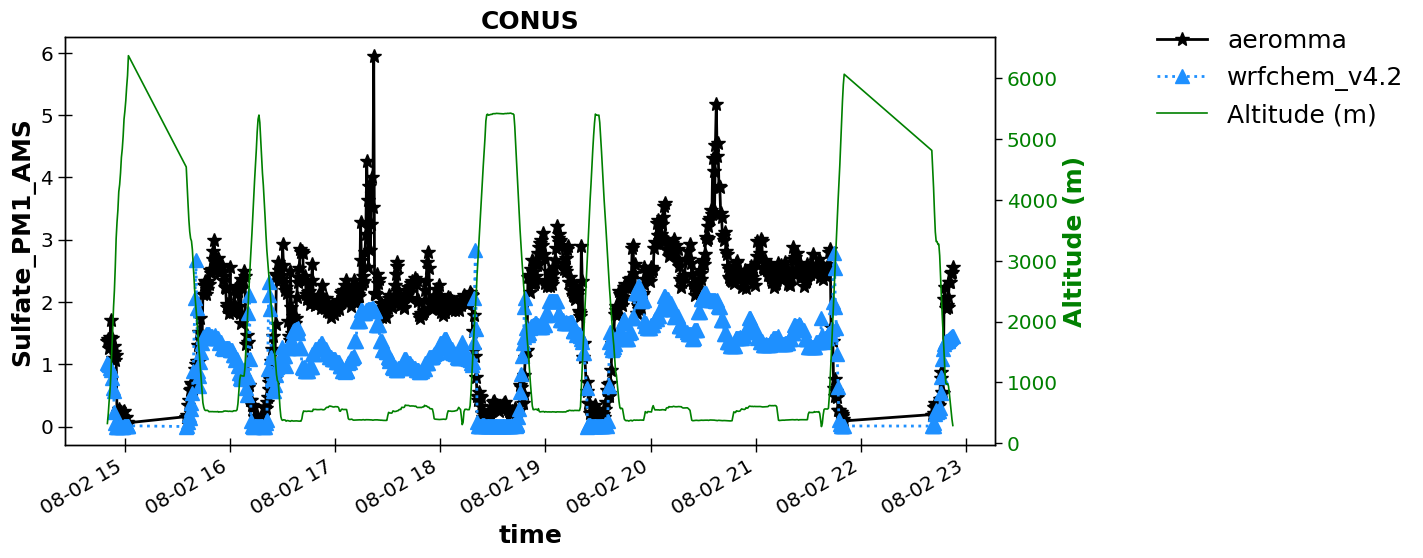

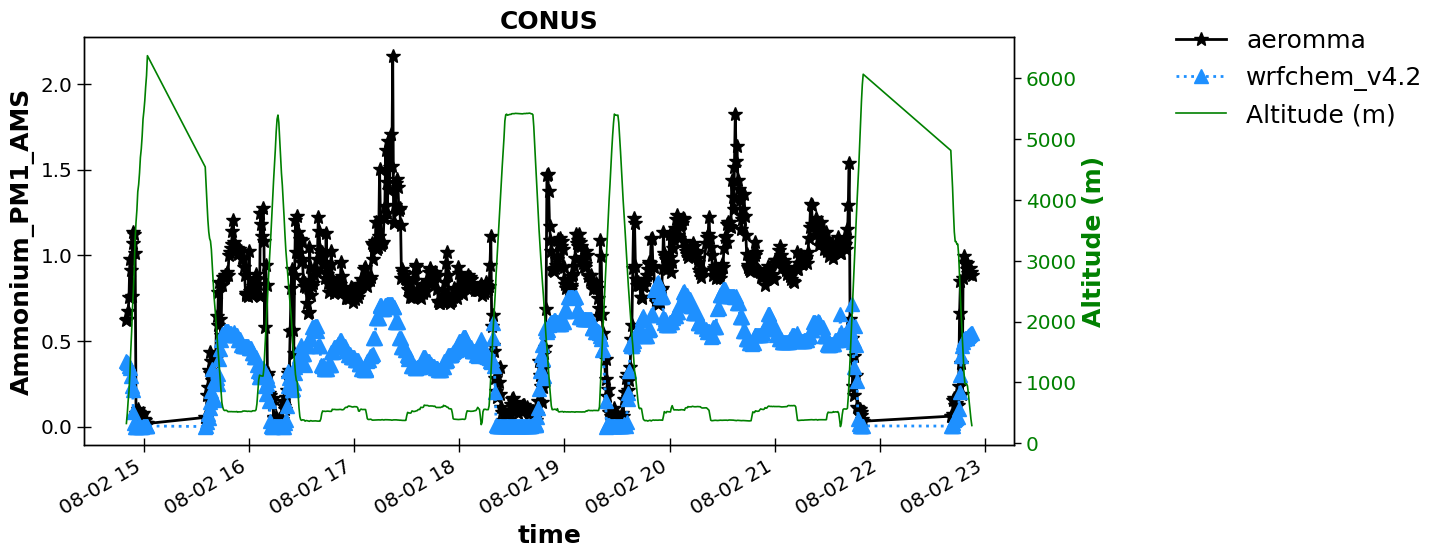

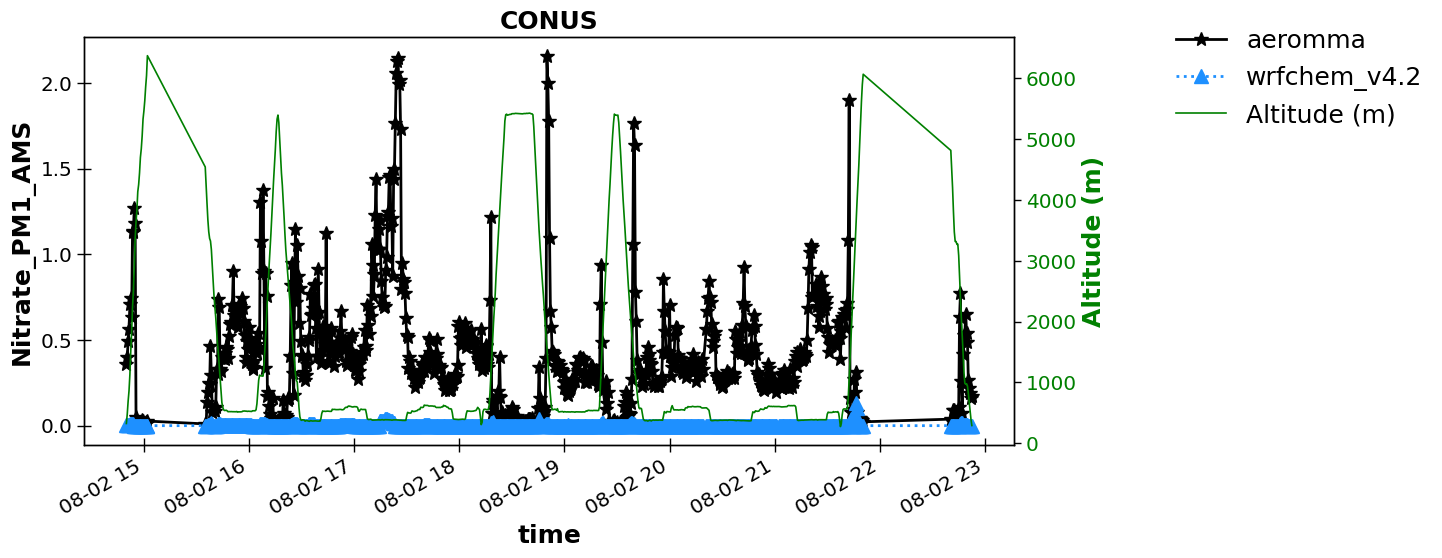

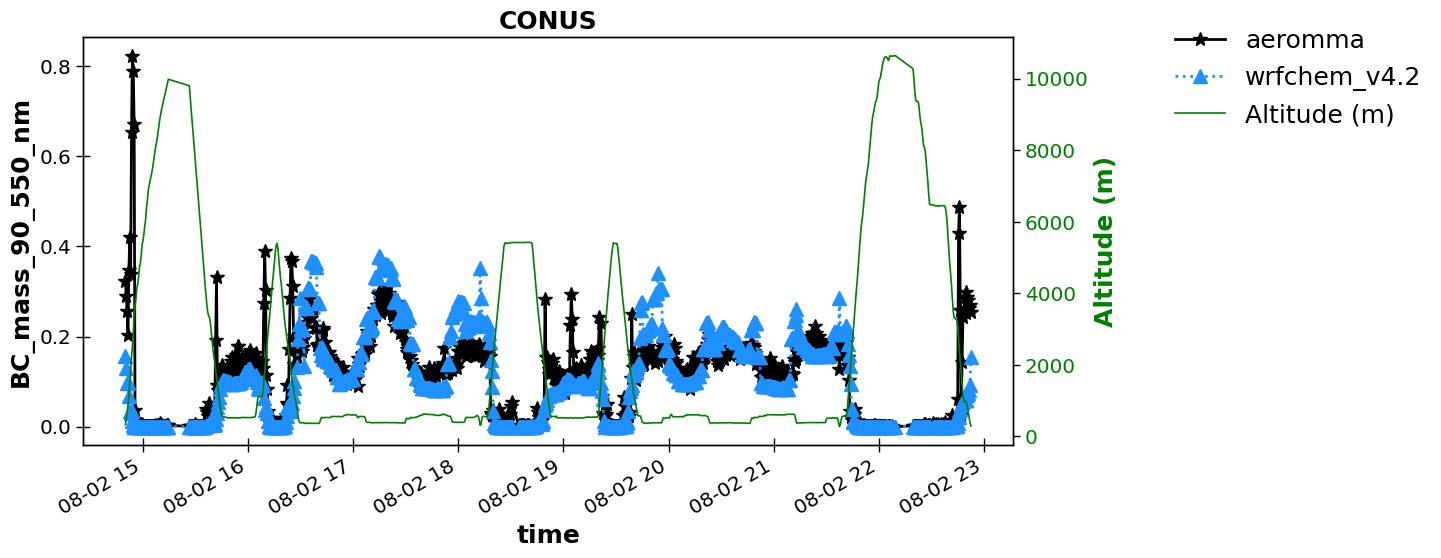

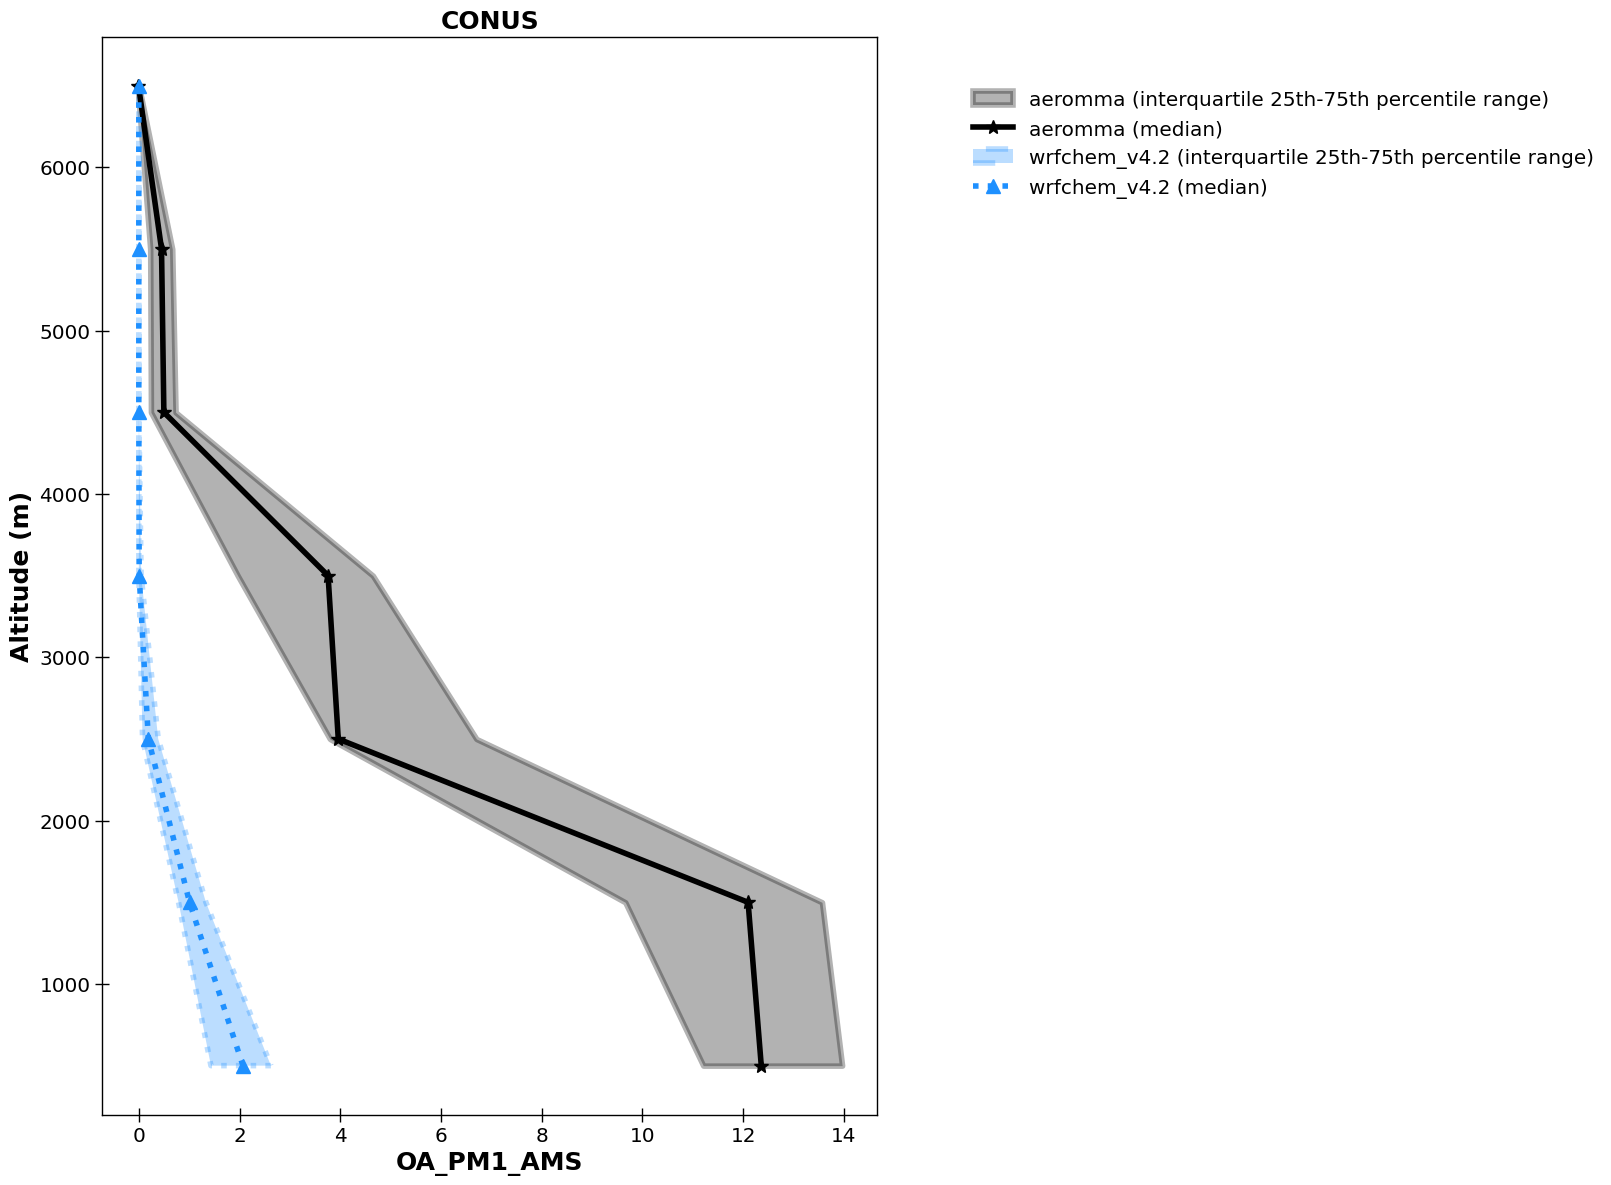

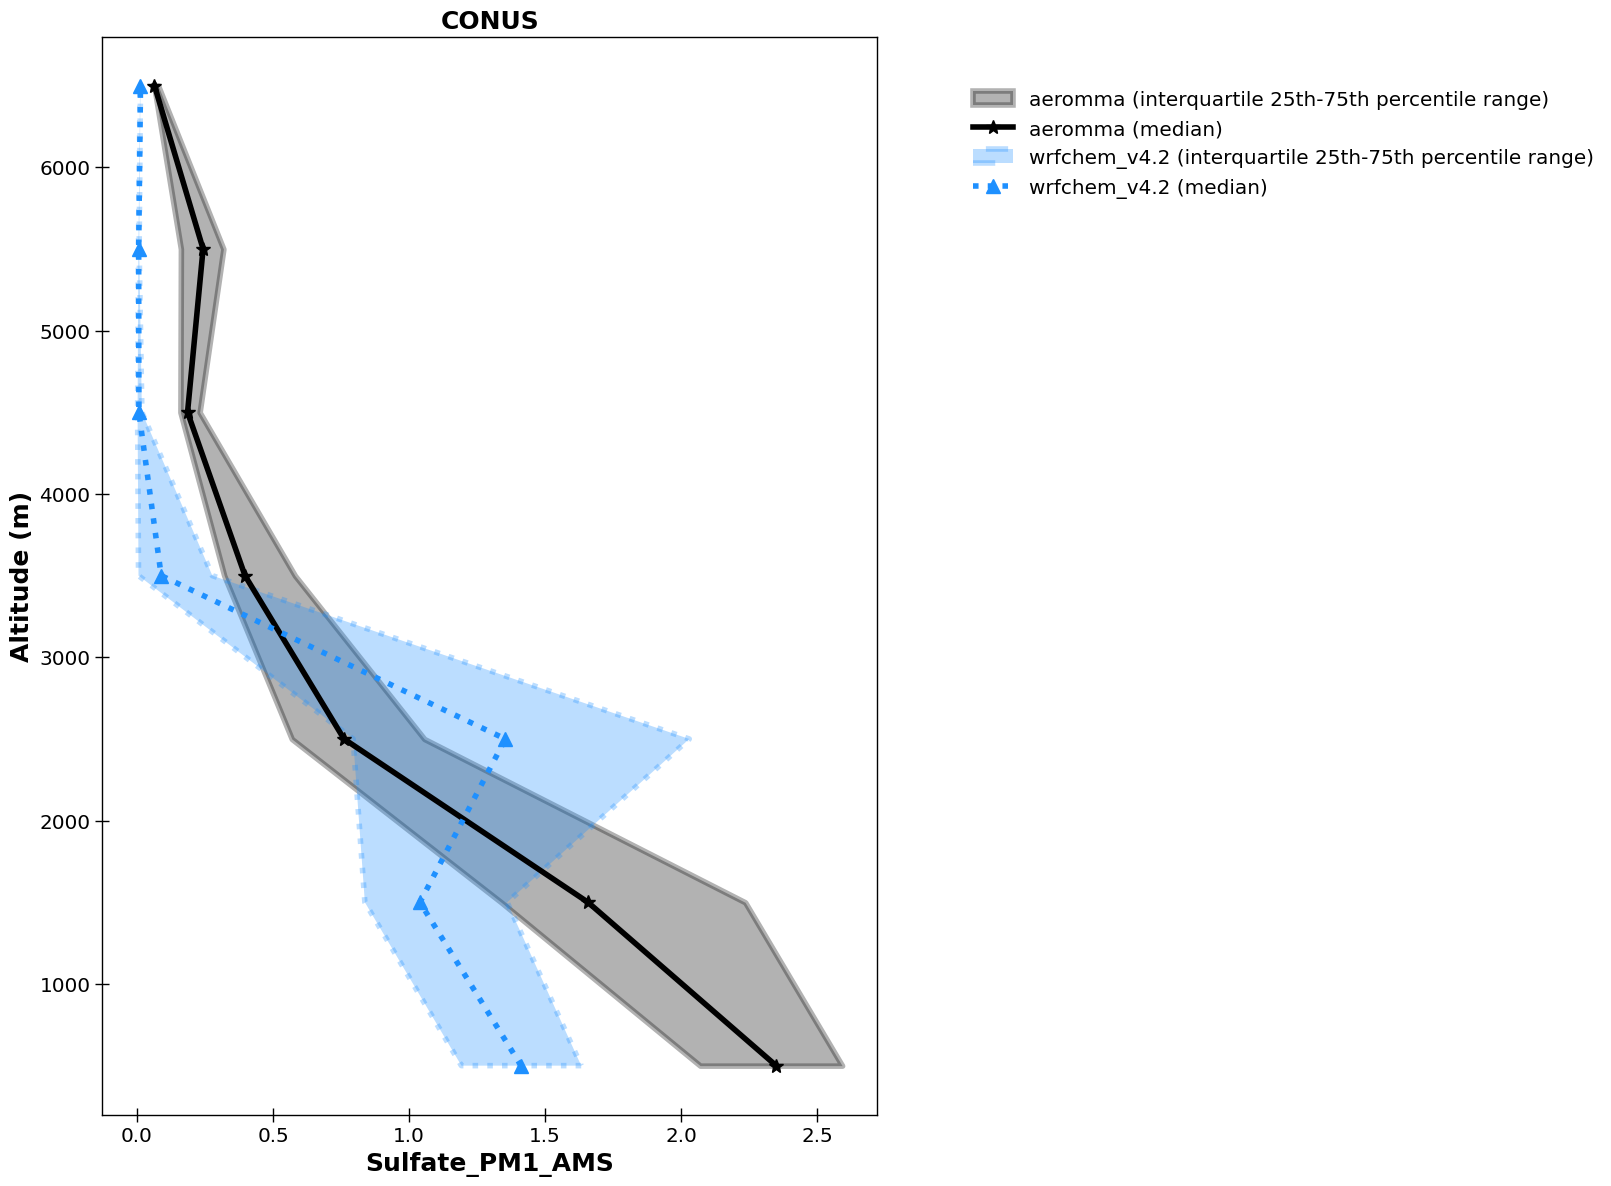

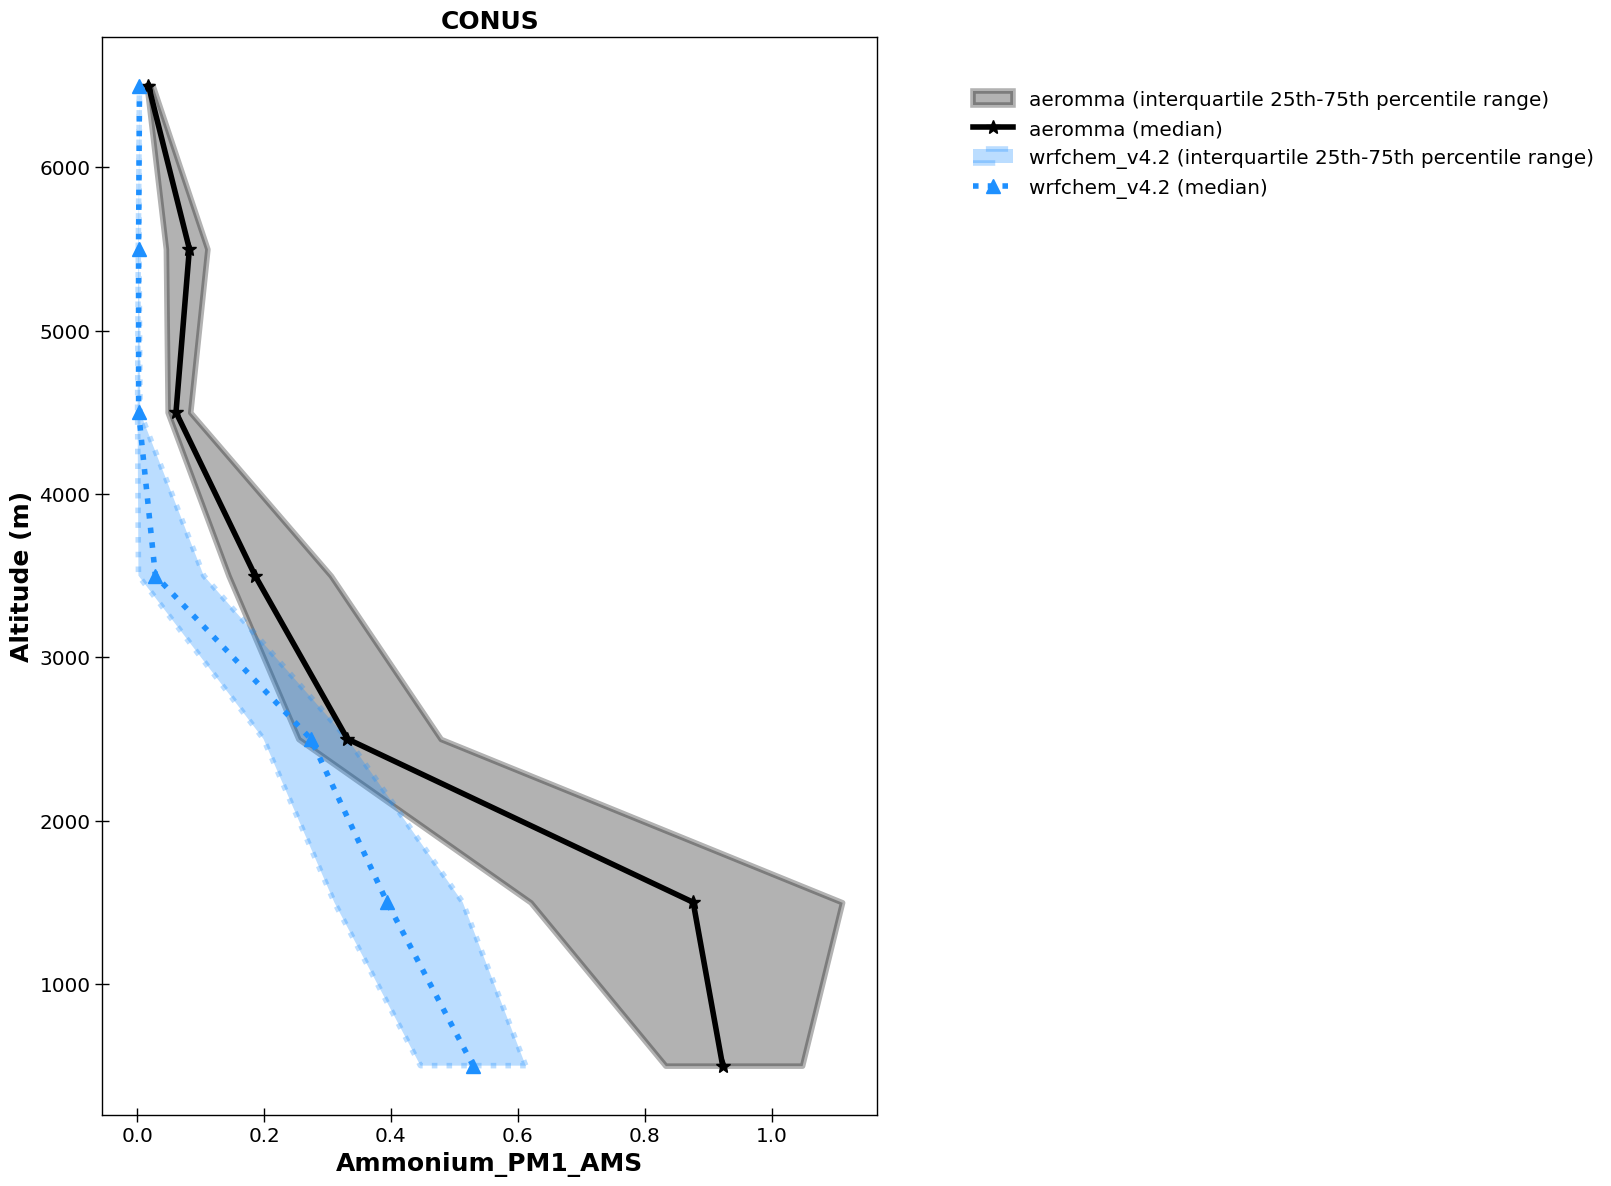

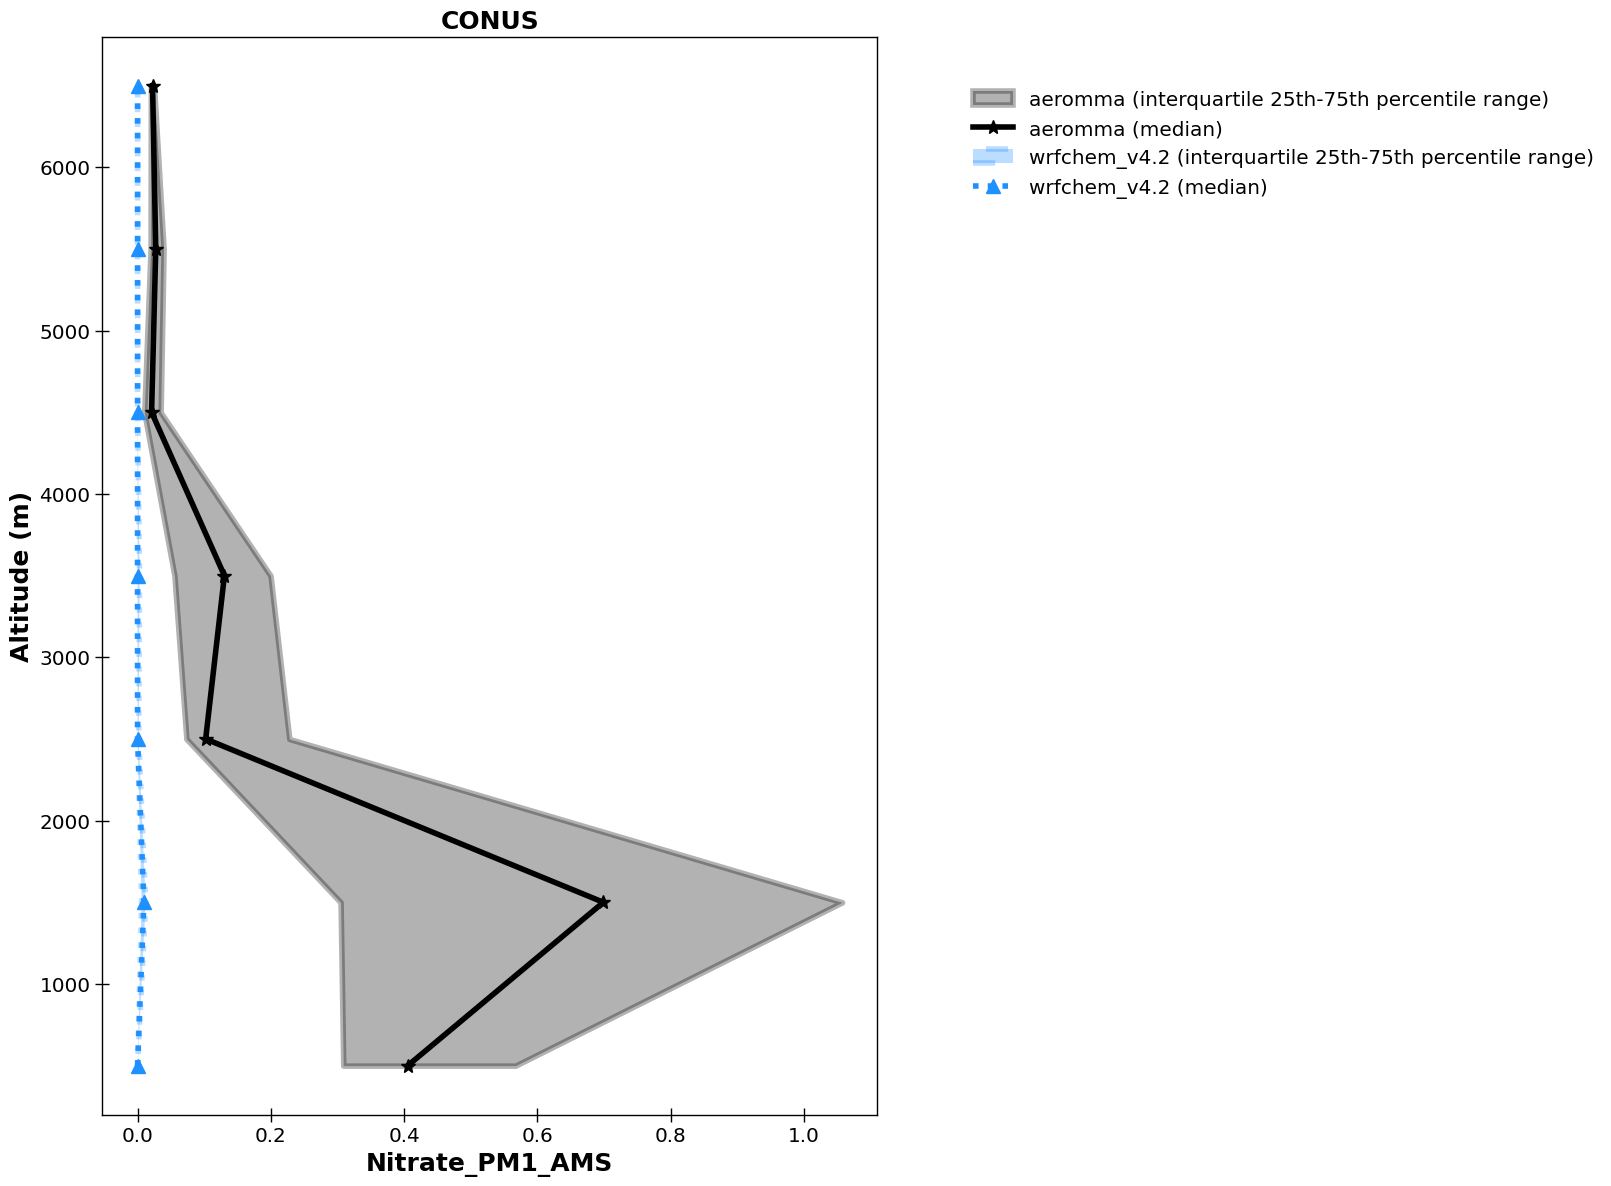

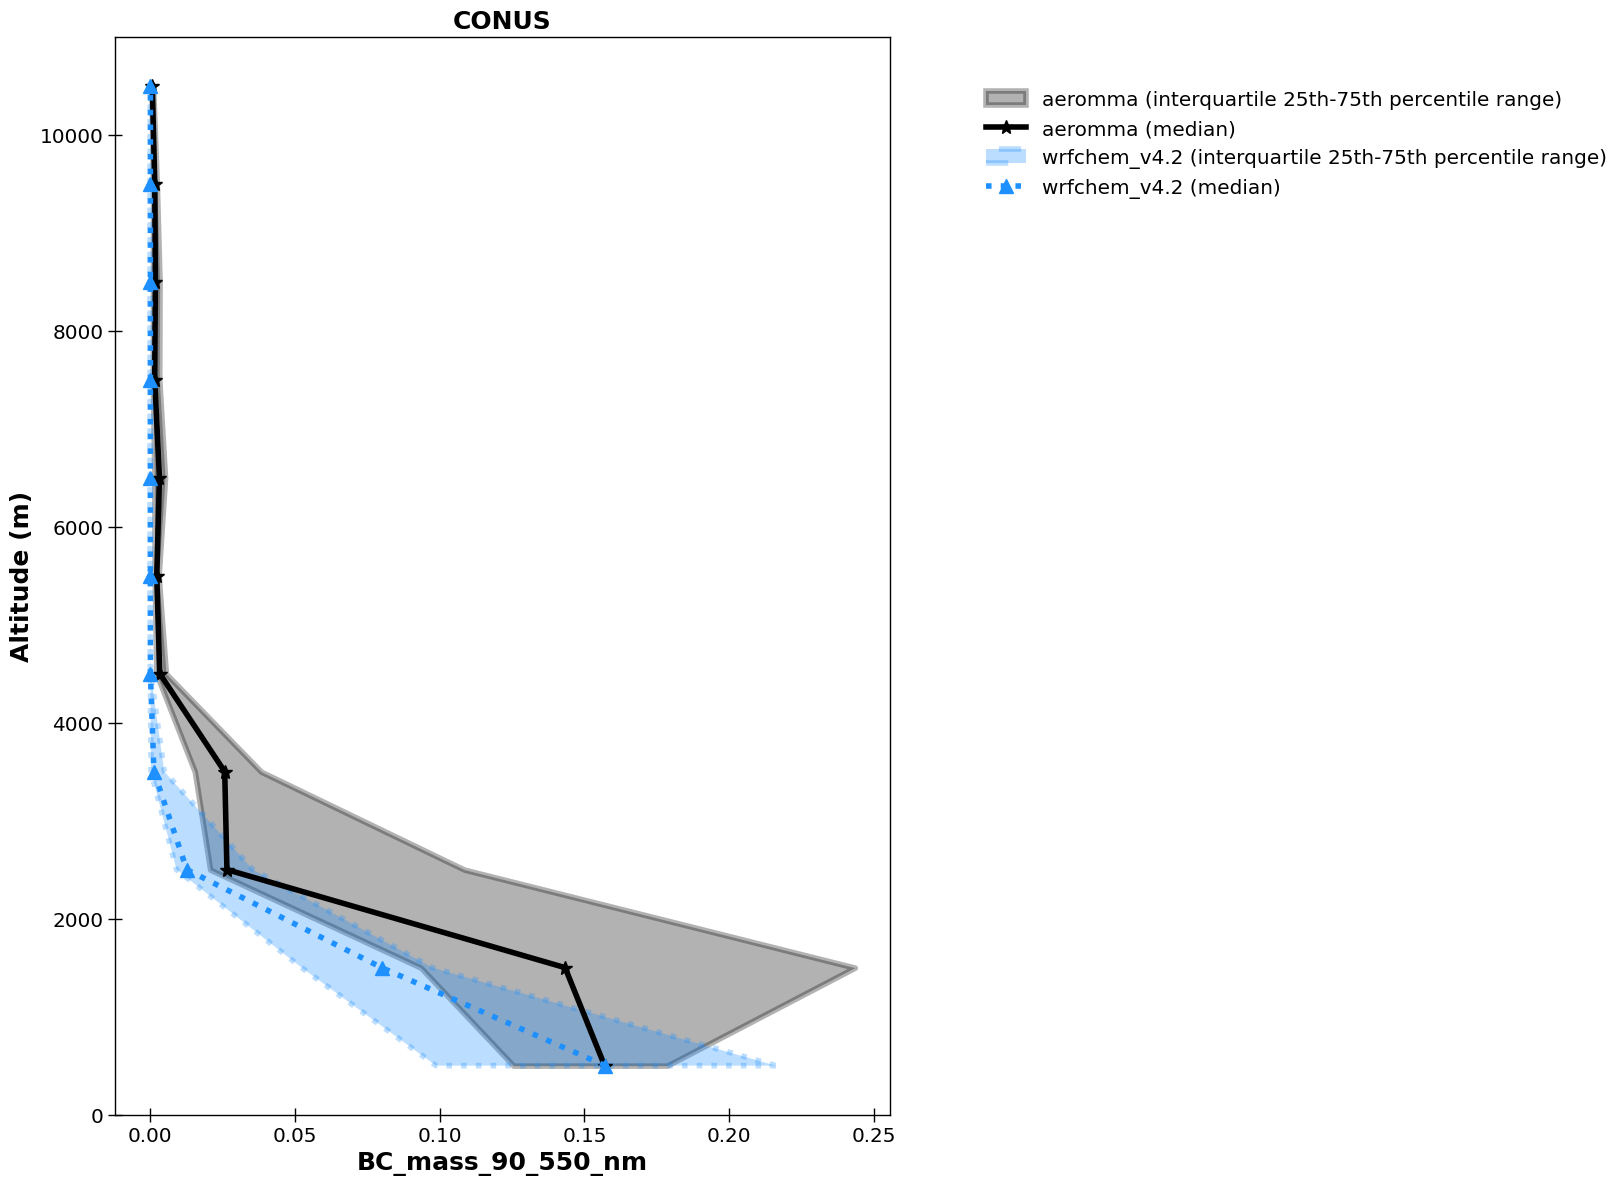

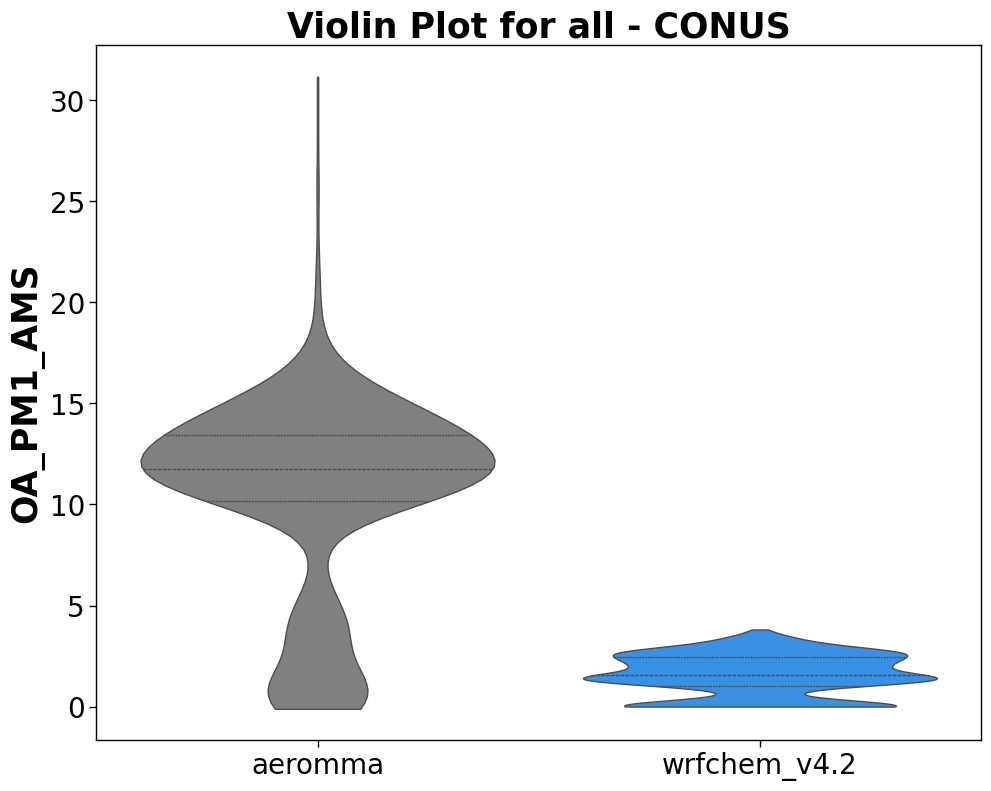

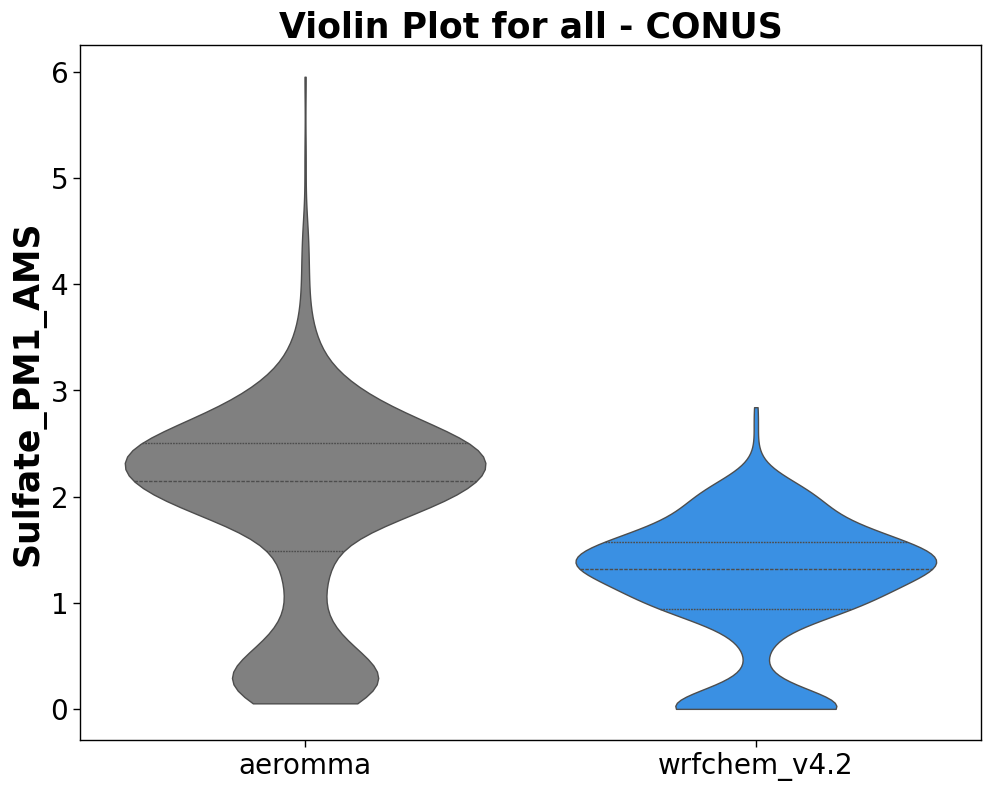

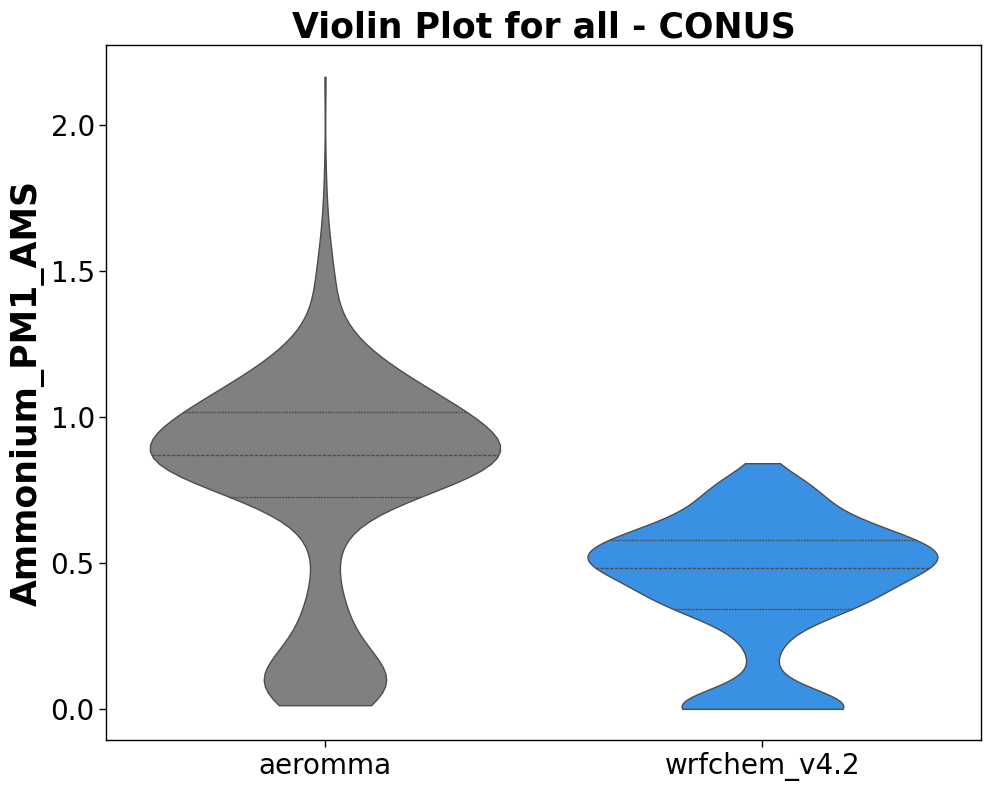

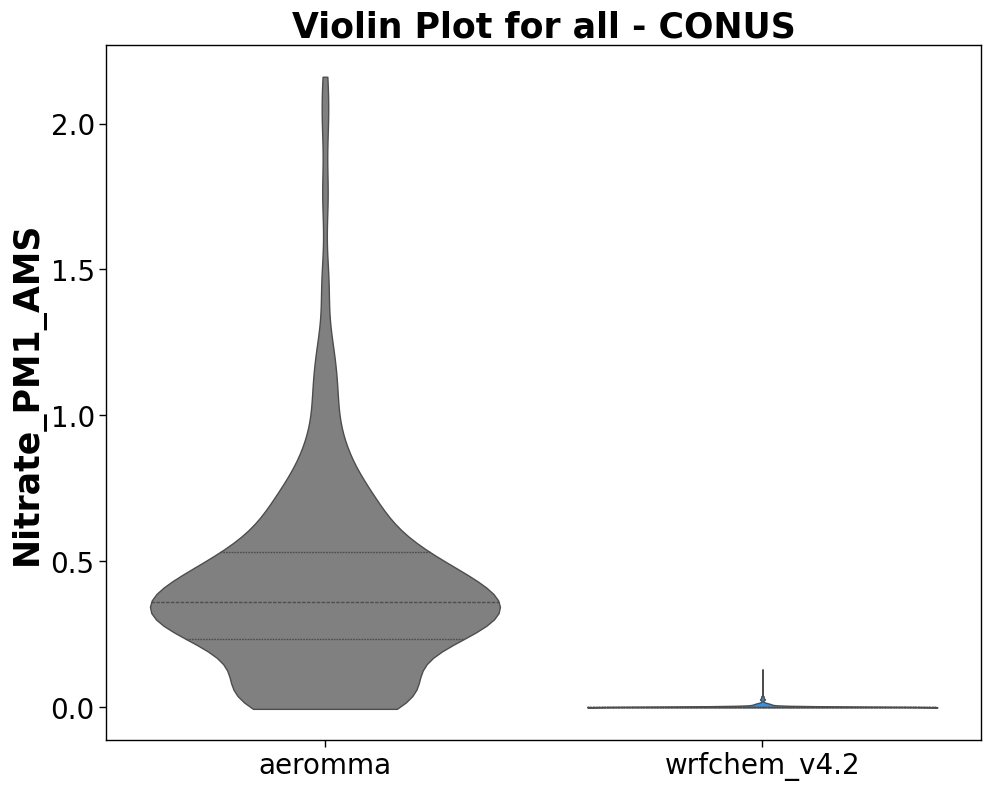

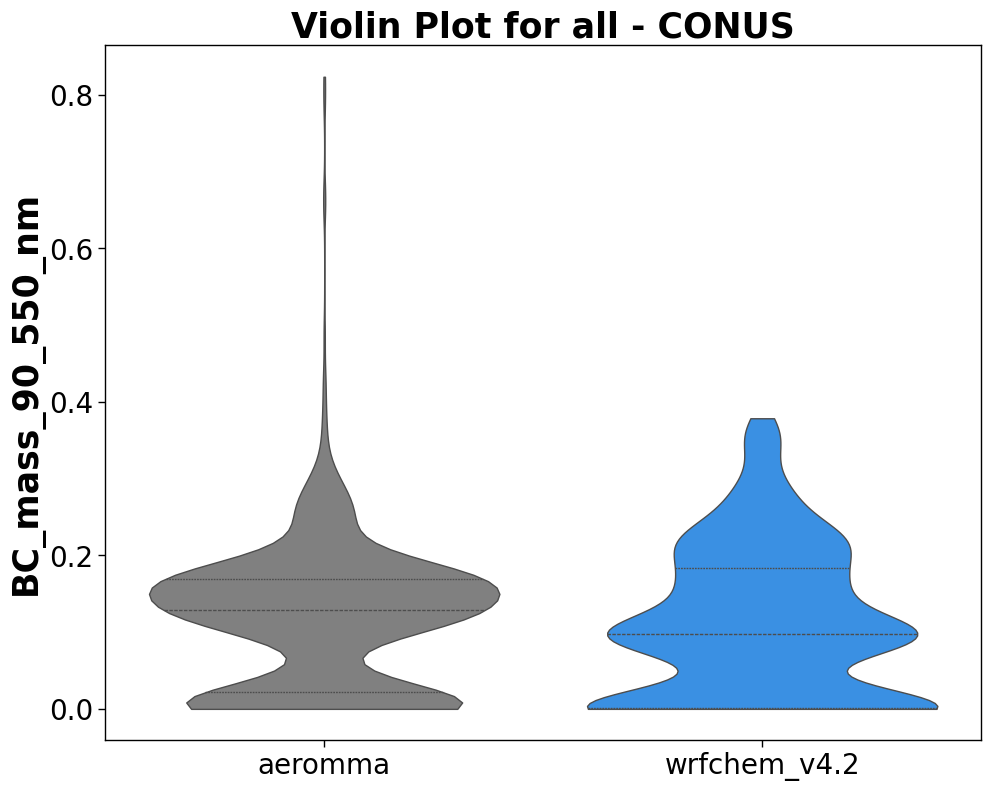

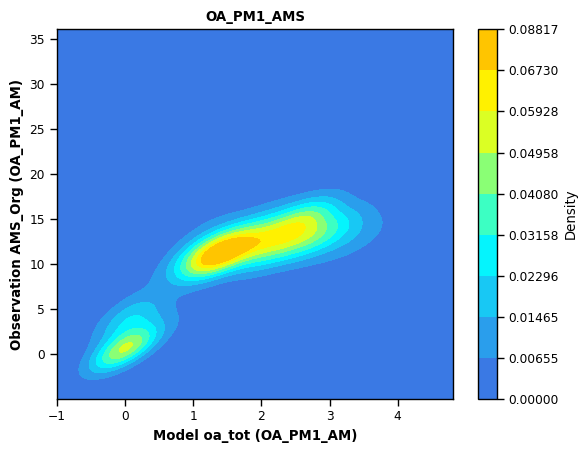

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_SO4.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...
Processing scatter density plot for model 'wrfchem_v4.2' and observation 'aeromma'...
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_SO4.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...


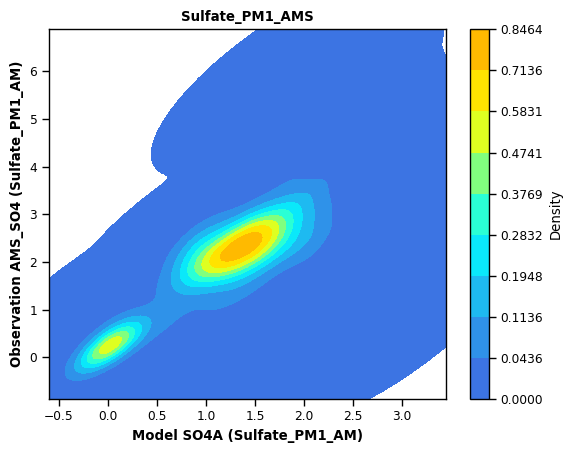

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_NH4.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...
Processing scatter density plot for model 'wrfchem_v4.2' and observation 'aeromma'...
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_NH4.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...


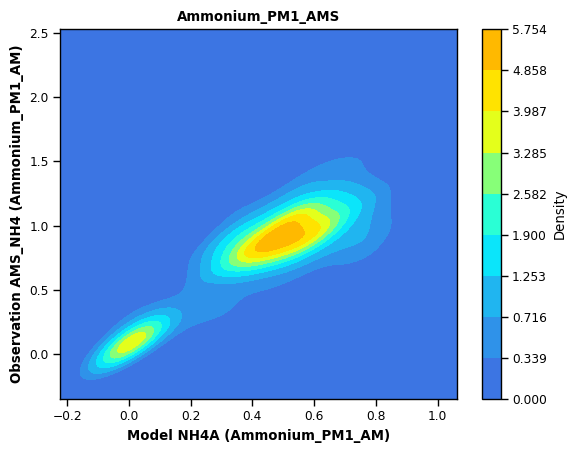

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_NO3.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...
Processing scatter density plot for model 'wrfchem_v4.2' and observation 'aeromma'...
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.AMS_NO3.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...


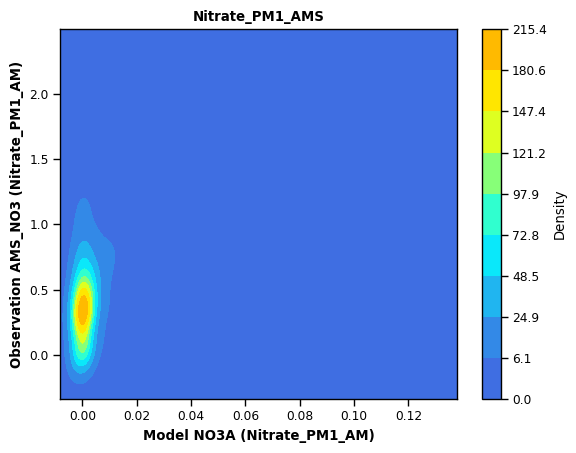

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.BC_mass_90_550_nm_amb.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...
Processing scatter density plot for model 'wrfchem_v4.2' and observation 'aeromma'...
Saving scatter density plot to ./output/sumvars/plot_grp4.scatter_density.BC_mass_90_550_nm_amb.2023-08-02_00.2023-08-02_23.all.CONUS_aeromma_vs_wrfchem_v4.2.png...


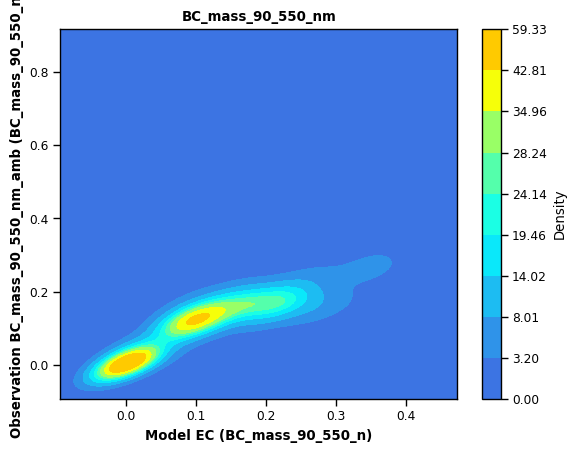

Reference std: 4.9512303141798535
Reference std: 0.9434498918287226
Reference std: 0.37179379245060673
Reference std: 0.33739728374040023
Reference std: 0.09450175834967961


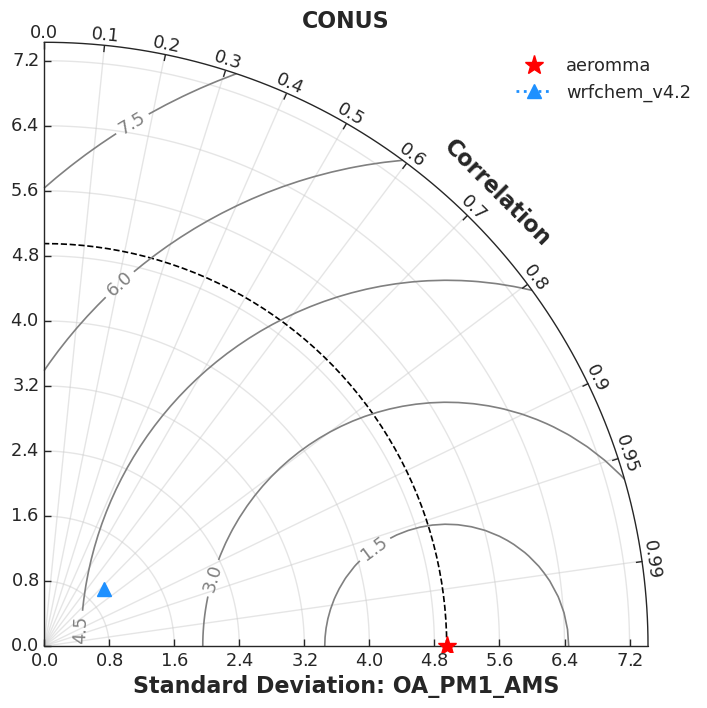

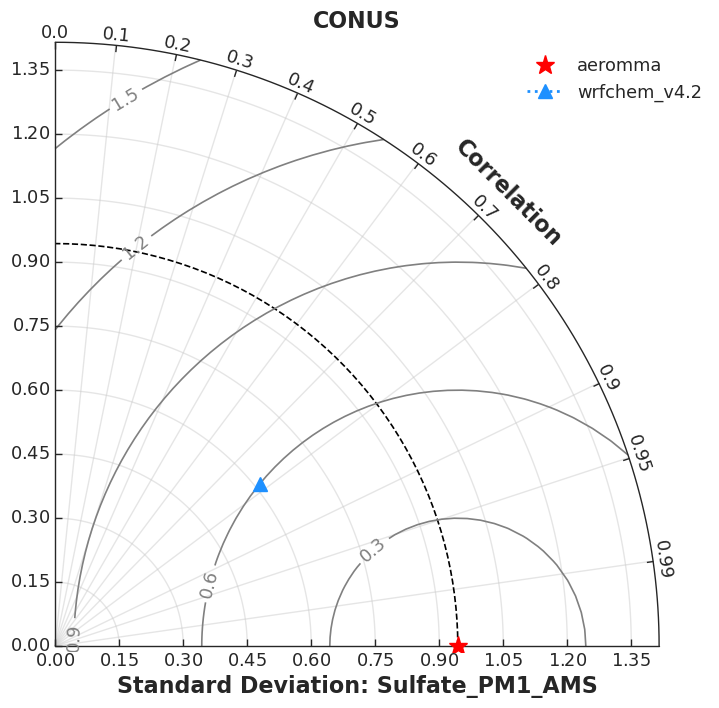

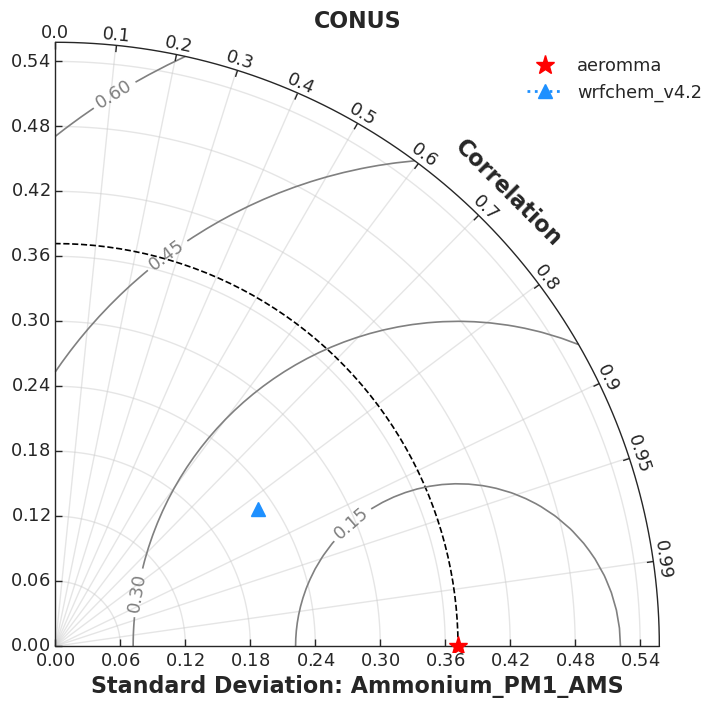

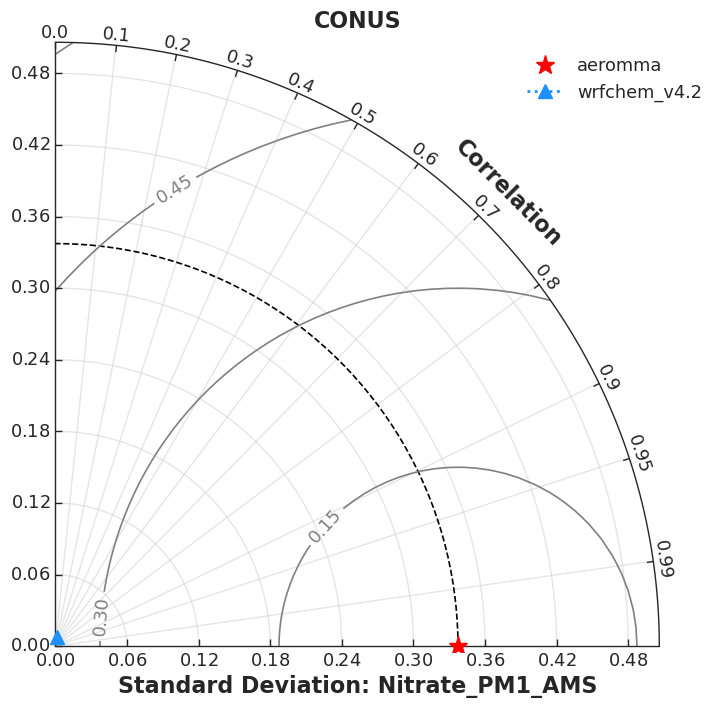

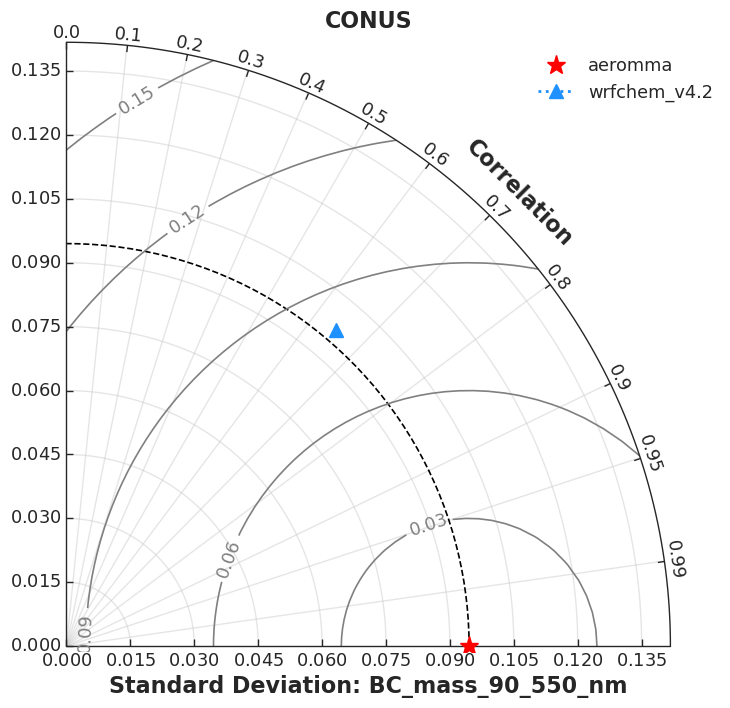

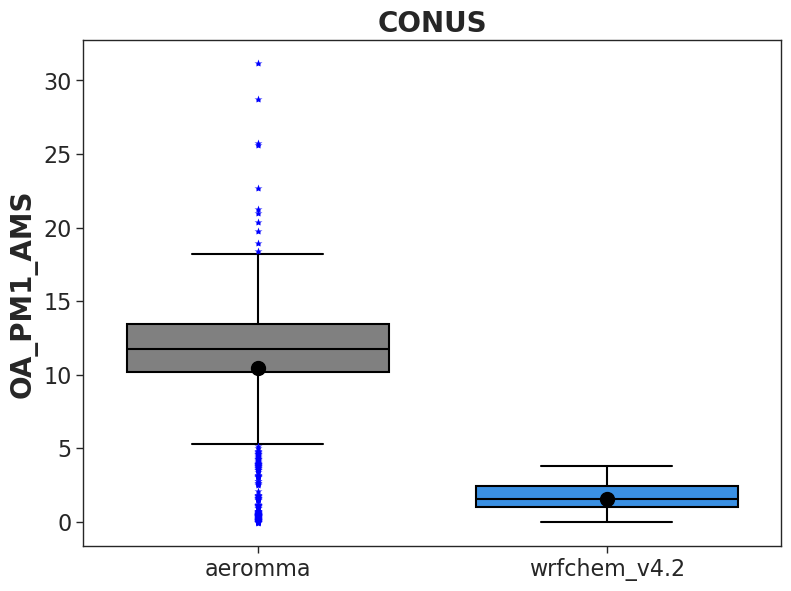

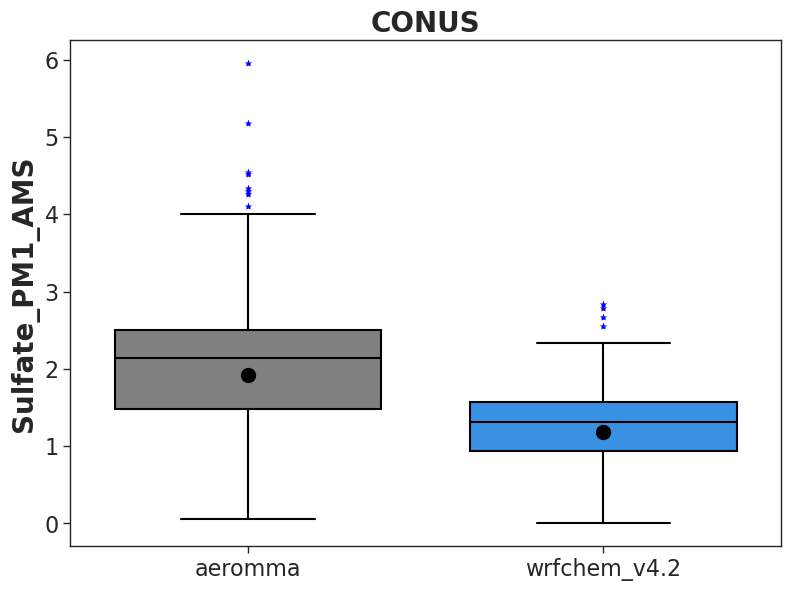

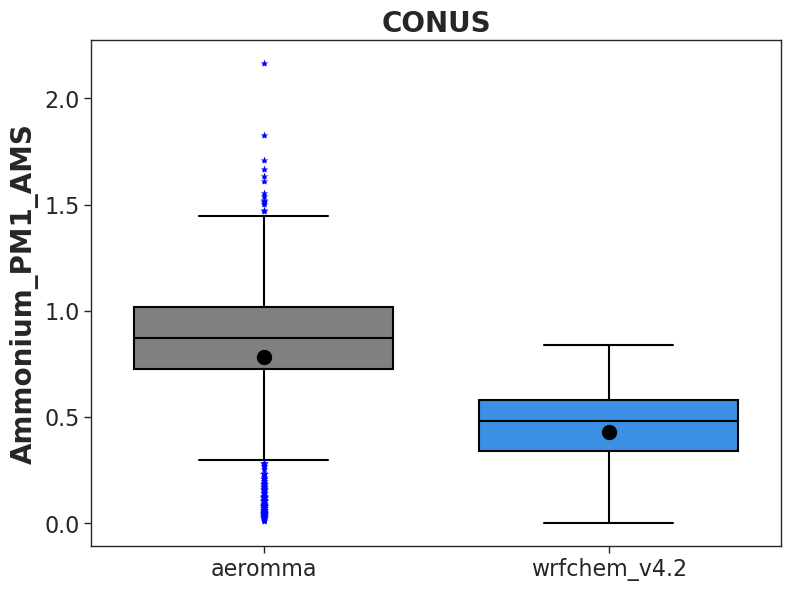

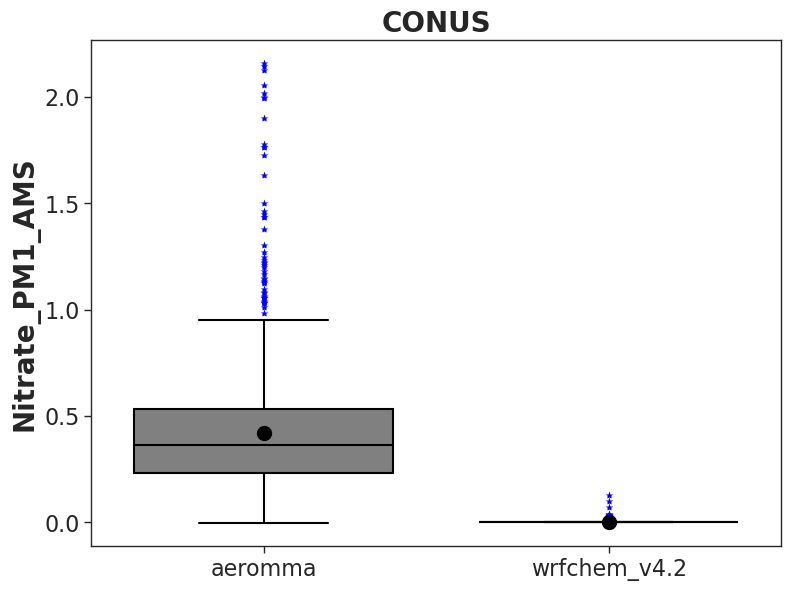

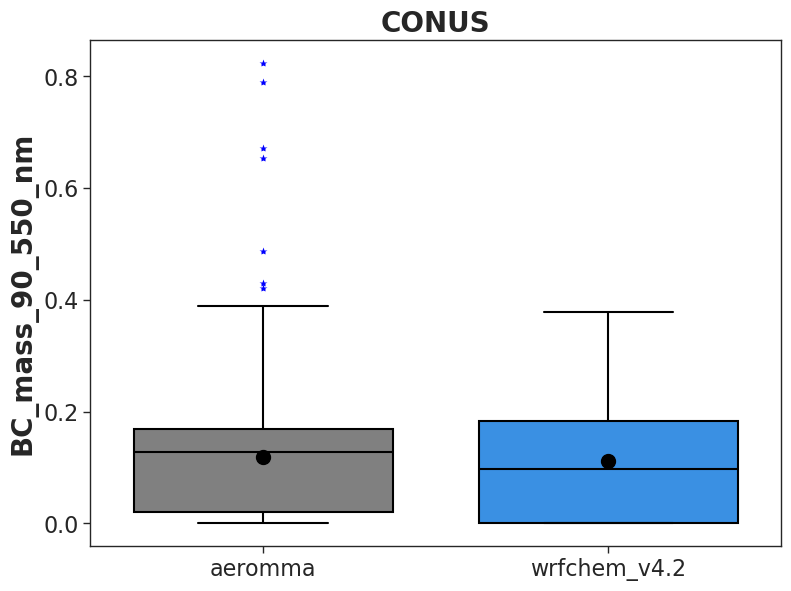

In [14]:
#And this generates all the plots.
an.plotting()

In [15]:
#Calculate stats
an.stats()  